In [ ]:
!pip install --upgrade datasets transformers scikit-learn accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from datasets import load_dataset
ds = load_dataset("chrissoria/trump-truth-social")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/12.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/32255 [00:00<?, ? examples/s]

In [ ]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['date', 'time', 'day_of_week', 'datetime', 'text', 'content_html', 'url', 'post_id', 'is_president', 'is_president_elect', 'replies_count', 'reblogs_count', 'favourites_count', 'media_urls', 'links', 'has_media', 'image_alt_text', 'sp500_open', 'sp500_close', 'sp500_1hr_before', 'sp500_5min_before', 'sp500_at_post', 'sp500_5min_after', 'sp500_1hr_after', 'sp500_resolution', 'dia_open', 'dia_close', 'dia_1hr_before', 'dia_5min_before', 'dia_at_post', 'dia_5min_after', 'dia_1hr_after', 'qqq_open', 'qqq_close', 'qqq_1hr_before', 'qqq_5min_before', 'qqq_at_post', 'qqq_5min_after', 'qqq_1hr_after', 'djt_open', 'djt_close', 'djt_1hr_before', 'djt_5min_before', 'djt_at_post', 'djt_5min_after', 'djt_1hr_after', 'lmt_open', 'lmt_close', 'lmt_1hr_before', 'lmt_5min_before', 'lmt_at_post', 'lmt_5min_after', 'lmt_1hr_after', 'war_open', 'war_close', 'war_1hr_before', 'war_5min_before', 'war_at_post', 'war_5min_after', 'war_1hr_after', 'cnrg_ope

In [ ]:
print(ds['train'][0])

{'date': '2026-03-27', 'time': '23:21:30', 'day_of_week': 'Friday', 'datetime': '2026-03-27T23:21:30.705Z', 'text': 'NY AG Letitia James referred again for criminal prosecution for alleged homeowner insurance fraud: https://justthenews.com/government/courts-law/545ny-ag-letitia-james-referred-again-criminal-prosecution-homeowner', 'content_html': 'NY AG Letitia James referred again for criminal prosecution for alleged homeowner insurance fraud: https://justthenews.com/government/courts-law/545ny-ag-letitia-james-referred-again-criminal-prosecution-homeowner', 'url': 'https://truthsocial.com/@realDonaldTrump/116303704274241748', 'post_id': '116303704274241748', 'is_president': True, 'is_president_elect': False, 'replies_count': 2908, 'reblogs_count': 5021, 'favourites_count': 18825, 'media_urls': '', 'links': '', 'has_media': False, 'image_alt_text': None, 'sp500_open': 6453.89, 'sp500_close': 6368.85, 'sp500_1hr_before': 6367.77, 'sp500_5min_before': 6367.77, 'sp500_at_post': 6367.77, 

In [ ]:
print(ds['train'].column_names)

['date', 'time', 'day_of_week', 'datetime', 'text', 'content_html', 'url', 'post_id', 'is_president', 'is_president_elect', 'replies_count', 'reblogs_count', 'favourites_count', 'media_urls', 'links', 'has_media', 'image_alt_text', 'sp500_open', 'sp500_close', 'sp500_1hr_before', 'sp500_5min_before', 'sp500_at_post', 'sp500_5min_after', 'sp500_1hr_after', 'sp500_resolution', 'dia_open', 'dia_close', 'dia_1hr_before', 'dia_5min_before', 'dia_at_post', 'dia_5min_after', 'dia_1hr_after', 'qqq_open', 'qqq_close', 'qqq_1hr_before', 'qqq_5min_before', 'qqq_at_post', 'qqq_5min_after', 'qqq_1hr_after', 'djt_open', 'djt_close', 'djt_1hr_before', 'djt_5min_before', 'djt_at_post', 'djt_5min_after', 'djt_1hr_after', 'lmt_open', 'lmt_close', 'lmt_1hr_before', 'lmt_5min_before', 'lmt_at_post', 'lmt_5min_after', 'lmt_1hr_after', 'war_open', 'war_close', 'war_1hr_before', 'war_5min_before', 'war_at_post', 'war_5min_after', 'war_1hr_after', 'cnrg_open', 'cnrg_close', 'cnrg_1hr_before', 'cnrg_5min_befor

In [ ]:
text_col = 'text'

In [ ]:
import pandas as pd

text_col = "text"  # change if needed

df = pd.DataFrame(ds['train'])

df = df[[text_col]].dropna()
df = df[df[text_col].str.len() > 10]

df.reset_index(drop=True, inplace=True)

print(df.head())

                                                text
0  NY AG Letitia James referred again for crimina...
1  U.S. intercepted Ukraine government messages d...
2  TrumpRX website sees steady growth in prescrip...
3  The Republicans should TERMINATE THE FILIBUSTE...
4  Going to make a big speech on economics in Mia...


In [ ]:
from transformers import pipeline

sentiment_pipe = pipeline("sentiment-analysis")

def get_label(text):
    try:
        res = sentiment_pipe(text[:512])[0]
        return 1 if res['label'] == 'POSITIVE' else 0
    except:
        return 0

df['label'] = df[text_col].apply(get_label)

print(df['label'].value_counts())

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


label
0    16317
1    10013
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[text_col],
    df['label'],
    test_size=0.1,
    random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      1646
           1       0.86      0.70      0.77       987

    accuracy                           0.84      2633
   macro avg       0.85      0.82      0.83      2633
weighted avg       0.85      0.84      0.84      2633



In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Results:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1646
           1       0.85      0.64      0.73       987

    accuracy                           0.82      2633
   macro avg       0.83      0.78      0.80      2633
weighted avg       0.82      0.82      0.81      2633



In [ ]:
from datasets import Dataset

hf_df = Dataset.from_pandas(df)

hf_df = hf_df.train_test_split(test_size=0.1)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(example[text_col], truncation=True, padding='max_length')

hf_df = hf_df.map(tokenize, batched=True)

hf_df.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/23697 [00:00<?, ? examples/s]

Map:   0%|          | 0/2633 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_df["train"],
    eval_dataset=hf_df["test"],
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.278730,0.289748
2,0.128657,0.336376


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5926, training_loss=0.21309708148854592, metrics={'train_runtime': 2486.8844, 'train_samples_per_second': 19.058, 'train_steps_per_second': 2.383, 'total_flos': 6278159891902464.0, 'train_loss': 0.21309708148854592, 'epoch': 2.0})

In [ ]:
import numpy as np
import torch
from sklearn.metrics import classification_report

# Use the 'trainer' object that was just trained
# (Assuming the 'trainer' object from bhdGQDqxsWjK is still available and in a good state)

# Get predictions from the trained model using the trainer's predict method
predictions_output = trainer.predict(hf_df["test"])

# Extract predicted labels (argmax of logits)
y_pred_labels = np.argmax(predictions_output.predictions, axis=1)

# Extract true labels
y_true_labels = predictions_output.label_ids

print("Evaluation Results (using trainer.predict):")
print(classification_report(y_true_labels, y_pred_labels))

Evaluation Results (using trainer.predict):
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1659
           1       0.89      0.92      0.90       974

    accuracy                           0.93      2633
   macro avg       0.92      0.93      0.92      2633
weighted avg       0.93      0.93      0.93      2633



In [ ]:
import os

# Define the directory to save the model and tokenizer
save_directory = './sentiment_model'

# Create the directory if it doesn't exist
os.makedirs(save_directory, exist_ok=True)

# Save the model and tokenizer
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"Model and tokenizer saved to: {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: ./sentiment_model


Now that the model and tokenizer are saved to the `./sentiment_model` directory, you can create a separate Python file (e.g., `predict_sentiment.py`) with the following code to load them and perform sentiment analysis.

In [ ]:
predict_sentiment_script_content = '''
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import os

# Define the path to the saved model and tokenizer
save_directory = './sentiment_model'

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(save_directory)

# Load the model
model = AutoModelForSequenceClassification.from_pretrained(save_directory)

# Move the model to the appropriate device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval() # Set the model to evaluation mode

def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    # Move inputs to the same device as the model
    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred = outputs.logits.argmax().item()
    return "POSITIVE" if pred == 1 else "NEGATIVE"

if __name__ == "__main__":
    text_to_analyze = "This is an absolutely fantastic and groundbreaking policy!"
    sentiment = predict_sentiment(text_to_analyze)
    print(f"The sentiment of \"{text_to_analyze}\" is: {sentiment}")

    text_to_analyze_negative = "I am very disappointed with this terrible decision."
    sentiment_negative = predict_sentiment(text_to_analyze_negative)
    print(f"The sentiment of \"{text_to_analyze_negative}\" is: {sentiment_negative}")
'''

# You can save this content to a file named 'predict_sentiment.py'
# For example, in Colab, you can do:
with open('predict_sentiment.py', 'w') as f:
    f.write(predict_sentiment_script_content)

print("Content for 'predict_sentiment.py' has been created. You can find the file in your current directory.")
print("To run it, open a terminal in Colab and execute: `python predict_sentiment.py`")

Content for 'predict_sentiment.py' has been created. You can find the file in your current directory.
To run it, open a terminal in Colab and execute: `python predict_sentiment.py`


In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device) # Ensure the model is on the correct device

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    # Move inputs to the same device as the model
    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred = outputs.logits.argmax().item()
    return "POSITIVE" if pred == 1 else "NEGATIVE"

print(predict("Israel attacks west bank"))
print(predict("India's GDP touches 4.5% growth this quartet"))

NEGATIVE
POSITIVE


# EDA

In [ ]:
!pip install datasets pandas matplotlib seaborn wordcloud

In [ ]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("chrissoria/trump-truth-social")

df = pd.DataFrame(ds['train'])

print("Shape:", df.shape)
print(df.head())

Shape: (32255, 187)
         date      time day_of_week                  datetime  \
0  2026-03-27  23:21:30      Friday  2026-03-27T23:21:30.705Z   
1  2026-03-27  23:21:06      Friday  2026-03-27T23:21:06.236Z   
2  2026-03-27  23:20:41      Friday  2026-03-27T23:20:41.842Z   
3  2026-03-27  19:21:13      Friday  2026-03-27T19:21:13.557Z   
4  2026-03-27  18:16:32      Friday  2026-03-27T18:16:32.157Z   

                                                text  \
0  NY AG Letitia James referred again for crimina...   
1  U.S. intercepted Ukraine government messages d...   
2  TrumpRX website sees steady growth in prescrip...   
3  The Republicans should TERMINATE THE FILIBUSTE...   
4  Going to make a big speech on economics in Mia...   

                                        content_html  \
0  NY AG Letitia James referred again for crimina...   
1  U.S. intercepted Ukraine government messages d...   
2  TrumpRX website sees steady growth in prescrip...   
3  The Republicans should TE

In [ ]:
print(df.info())
print("\nColumns:", df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32255 entries, 0 to 32254
Columns: 187 entries, date to cat_other
dtypes: bool(3), float64(155), int64(14), object(15)
memory usage: 45.4+ MB
None

Columns: ['date', 'time', 'day_of_week', 'datetime', 'text', 'content_html', 'url', 'post_id', 'is_president', 'is_president_elect', 'replies_count', 'reblogs_count', 'favourites_count', 'media_urls', 'links', 'has_media', 'image_alt_text', 'sp500_open', 'sp500_close', 'sp500_1hr_before', 'sp500_5min_before', 'sp500_at_post', 'sp500_5min_after', 'sp500_1hr_after', 'sp500_resolution', 'dia_open', 'dia_close', 'dia_1hr_before', 'dia_5min_before', 'dia_at_post', 'dia_5min_after', 'dia_1hr_after', 'qqq_open', 'qqq_close', 'qqq_1hr_before', 'qqq_5min_before', 'qqq_at_post', 'qqq_5min_after', 'qqq_1hr_after', 'djt_open', 'djt_close', 'djt_1hr_before', 'djt_5min_before', 'djt_at_post', 'djt_5min_after', 'djt_1hr_after', 'lmt_open', 'lmt_close', 'lmt_1hr_before', 'lmt_5min_before', 'lmt_at_post', 'l

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

ibit_at_post                 30500
ibit_5min_before             30500
ibit_1hr_before              30500
cat_attacking_opposition     25837
cat_self_promotion           25837
                             ...  
gdelt_threat_delta               1
gdelt_protest_delta              1
gdelt_sanctions_delta            1
gdelt_military_delta             1
gdelt_goldstein_avg_delta        1
Length: 115, dtype: int64


In [ ]:
text_col = "text"  # adjust if needed

df = df[[text_col]].dropna()
df = df[df[text_col].str.len() > 5]

df.reset_index(drop=True, inplace=True)

print("After cleaning:", df.shape)

After cleaning: (26422, 1)


In [ ]:
df['char_length'] = df[text_col].apply(len)
df['word_count'] = df[text_col].apply(lambda x: len(x.split()))

print(df[['char_length', 'word_count']].describe())

        char_length    word_count
count  26422.000000  26422.000000
mean     238.077133     33.429793
std      260.382439     46.346575
min        6.000000      1.000000
25%       82.000000      2.000000
50%      139.000000     15.000000
75%      303.000000     47.750000
max     2997.000000    514.000000


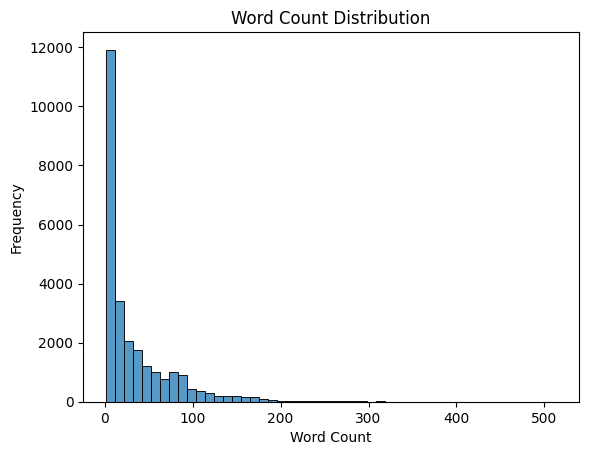

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from collections import Counter
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

all_words = " ".join(df[text_col].apply(clean_text)).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)
print(common_words)

[('the', 40133), ('and', 27289), ('to', 21925), ('of', 18941), ('a', 15809), ('in', 14028), ('is', 13348), ('for', 9378), ('our', 8608), ('that', 7607), ('will', 6993), ('i', 6927), ('rt', 6897), ('on', 6275), ('it', 5779), ('be', 5652), ('this', 5293), ('trump', 5054), ('he', 5017), ('are', 4885)]


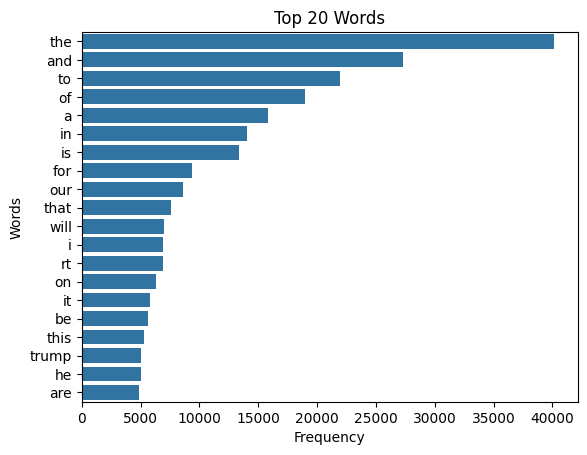

In [ ]:
words, counts = zip(*common_words)

plt.figure()
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

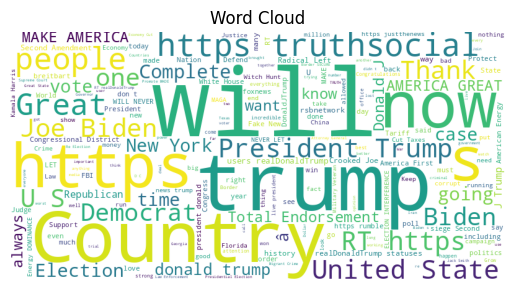

In [ ]:
from wordcloud import WordCloud

text_data = " ".join(df[text_col])

wc = WordCloud(width=800, height=400, background_color='white').generate(text_data)

plt.figure()
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20, stop_words='english')

X = vectorizer.fit_transform(df[text_col])

sum_words = X.sum(axis=0)

ngrams = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
ngrams = sorted(ngrams, key=lambda x: x[1], reverse=True)

print(ngrams[:20])

[('https www', np.int64(4868)), ('donald trump', np.int64(2027)), ('https truthsocial', np.int64(1807)), ('truthsocial com', np.int64(1807)), ('com users', np.int64(1652)), ('united states', np.int64(1564)), ('rt https', np.int64(1535)), ('president trump', np.int64(1502)), ('joe biden', np.int64(1439)), ('complete total', np.int64(1155)), ('com news', np.int64(1128)), ('new york', np.int64(1101)), ('total endorsement', np.int64(1087)), ('make america', np.int64(1037)), ('america great', np.int64(1027)), ('com politics', np.int64(966)), ('users realdonaldtrump', np.int64(949)), ('realdonaldtrump statuses', np.int64(949)), ('second amendment', np.int64(912)), ('crooked joe', np.int64(897))]


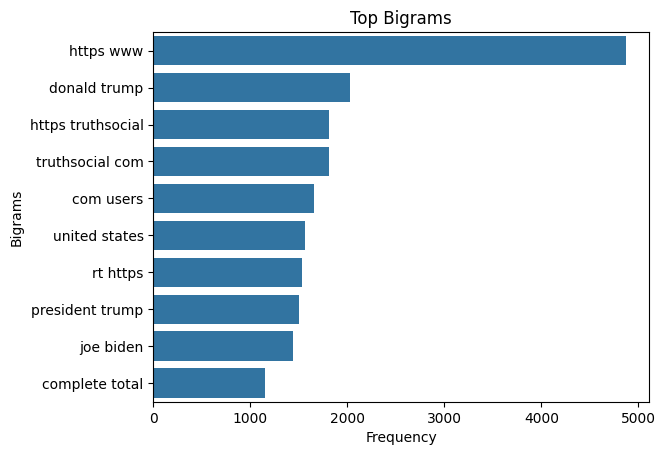

In [ ]:
words = [w[0] for w in ngrams[:10]]
counts = [w[1] for w in ngrams[:10]]

plt.figure()
sns.barplot(x=counts, y=words)
plt.title("Top Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

In [ ]:
for i in range(5):
    print(df[text_col][i])
    print("-"*80)

NY AG Letitia James referred again for criminal prosecution for alleged homeowner insurance fraud: https://justthenews.com/government/courts-law/545ny-ag-letitia-james-referred-again-criminal-prosecution-homeowner
--------------------------------------------------------------------------------
U.S. intercepted Ukraine government messages discussing plot to route money to Biden re-election: https://justthenews.com/government/security/nsa-intercepted-ukraine-government-messages-discussing-effort-route-money-2024
--------------------------------------------------------------------------------
TrumpRX website sees steady growth in prescription offerings, proving MAHA doubters wrong: https://justthenews.com/government/white-house/trumprx-website-sees-steady-growth-prescription-offerings-proving-maha
--------------------------------------------------------------------------------
The Republicans should TERMINATE THE FILIBUSTER, and VOTE! Haven't they had enough of this nonsense from the Radi

In [ ]:
df.columns

Index(['text', 'char_length', 'word_count'], dtype='object')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-apply sentiment labeling to the current df to ensure 'label' column exists
# Assuming sentiment_pipe and get_label function are still available from cell n1oYKeTPsGRg
if 'label' not in df.columns:
    # Ensure text_col is defined, if not, set a default
    if 'text_col' not in globals():
        text_col = 'text'
    df['label'] = df[text_col].apply(get_label)

sns.countplot(x=df['label'])
plt.title("Sentiment Distribution")
plt.show()